# Chapter 3: Flow Machine

## Recap from Chapter 2

In the previous chapter, we trained a model to map **noisy image → clean image**.

But we saw a limitation: When the noise level is very low, the model learns a shortcut — it just copies the input to output. This is called the **"trivial solution"** problem.

## The new idea: Predict the "flow"

Instead of predicting the clean image directly, we train the model to predict:

$$ 
\text{flow} = \text{clean image} - \text{noise}
$$

This is the **direction** from the noisy point to the clean point in image space.

### Why does this help?

- In low-noise situations, the flow is very small, so the model doesn't get stuck copying the input
- In high-noise situations, the flow is large, giving a strong learning signal
- This is like learning a **vector field** that tells us "how to move from noise to image"

**Mathematically:**

If we define a noisy image as:
$$ x_t = t \cdot \text{noise} + (1-t) \cdot \text{clean} $$

Then the target for our model becomes:
$$ \text{target} = \text{clean} - \text{noise} $$

Notice that:
$$ x_t + (1-t) \cdot \text{target} = \text{clean} $$

This formulation avoids the trivial solution because the target doesn't become zero when $t$ is small — it becomes the difference between clean and noise.

In [ ]:
import data
import utils
import torch
import models
from torch import nn, optim

## Model architecture (same as Chapter 2)

We reuse the same U-Net like architecture with skip connections, self-attention, and positional encoding.

In [ ]:
model = nn.Sequential(
    models.ResConvBlock(3, 32, 32, 8),
    models.SkipBlock(
        nn.AvgPool2d(2),
        models.ResConvBlock(32, 64, 64),
        models.SkipBlock(
            nn.AvgPool2d(2),
            models.ResConvBlock(64, 128, 128),
            models.SkipBlock(
                nn.AvgPool2d(2),
                models.ResConvBlock(128, 256, 256),
                models.PositionalEncoding2d(256),
                models.SelfAttention(256),
                models.ResConvBlock(256, 256, 128),
                nn.Upsample(scale_factor=2, mode='bilinear'),
            ),
            models.ResConvBlock(256, 128, 64),
            nn.Upsample(scale_factor=2, mode='bilinear'),
        ),
        models.ResConvBlock(128, 64, 32),
        nn.Upsample(scale_factor=2, mode='bilinear'),
    ),
    models.ResConvBlock(64, 32, 3, 8, last_layer=True),
)

## Dataset: Predict the flow (clean - noise)

For each clean image `y` and random noise, we create a noisy image:

$$ x = t \cdot \text{noise} + (1-t) \cdot y $$

But this time, **the target is not `y`** — it's `y - noise` (the flow).

In [ ]:
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train = True, normalize = False):
        self.cifar10 = data.get_cifar10(train=train, normalize=normalize)
    
    def __len__(self):
        return len(self.cifar10)
    
    def __getitem__(self, index):
        y, _ = self.cifar10[index]                    # clean image
        noise = torch.randn((3, 32, 32))              # random noise
        t = torch.rand(1)[0]                          # random noise level (0 to 1)
        x = t * noise + (1 - t) * y                   # noisy image
        return x, y - noise                           # target: flow (clean - noise)

dataloader = data.DataLoader(NoisyCIFAR10(), batch_size=50, shuffle=True)
optimizer = optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

## Sampling: Euler integration

Instead of directly predicting the image, we now have to **integrate** the flow.

Starting from pure noise, we iteratively update:

$$ \text{image} \leftarrow \text{image} + \text{model}(\text{image}) / \text{steps} $$

This is like moving a small step in the direction predicted by the model at each iteration.

The denominator `steps` ensures we take small steps so that we converge to the correct image.

In [ ]:
@torch.no_grad()
def sample(num, steps):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.randn((num, 3, 32, 32))             # start from pure noise
    for step in range(steps):
        images[step*num: step*num+num] = image = image + model(image) / steps
    return images

## Training and results

Let's sample before training, then train for 3 epochs and observe the improvement.

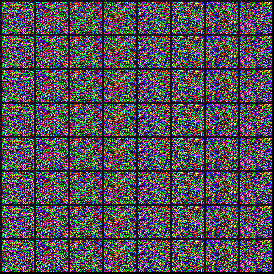

Loss: 0.132386: 100%|██████████| 1000/1000 [14:49<00:00,  1.12it/s]


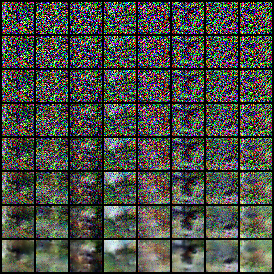

Loss: 0.12149: 100%|██████████| 1000/1000 [15:53<00:00,  1.05it/s]


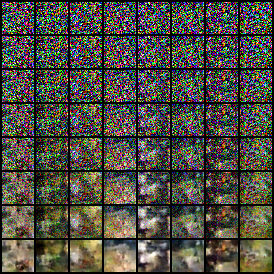

Loss: 0.115893: 100%|██████████| 1000/1000 [15:06<00:00,  1.10it/s]


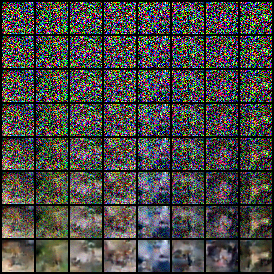

In [5]:
demo = sample(8, 8)
utils.show_image(demo)
for i in range(3):
    utils.train(model, dataloader, optimizer, loss_fn)
    demo = sample(8, 8)
    utils.show_image(demo)